### Regression
    - Predicting a continuous variable. Find the best fit line.

### Classification
    - Predicting a categorical value

#### Linear Regression
    - Regression problem with linear data e.g linear relation of x and y, can have multiple input variables.
    - Simple Linear Regression
    - Multiple Linear Regression
    - etc

- We have to minimize the errors, no errors means overfitting
- MSE is used to identify errors.
- RMSE is used to find how close are our values are from the predicted values. ITs the squared root of the variance of the residuals ( random errors or pred - orig ).
- R^2 - How much our model covers the variance (phelao) of the data. The higher it is the better our model is. R2 = 1 - (RSS/TSS)
- MSE, RMSE, R^2, RSS, TSS - Metric Evaluations

#### Simple Linear Regression Assumptions:
    - Linearity of Residuals
    - Independece of residuals
    - Normal Distribution of the residuals

# Linear Regression

Linear Regression is a supervised learning algorithm used for regression problems. It models the relationship between a dependent variable and one or more independent variables by fitting a linear equation to observed data. The goal is to find the best-fitting line that minimizes the sum of squared differences between the observed values and the predicted values.

In [2]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [58]:
# load the data tips from sns
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [59]:
df['total_bill'].max()

np.float64(50.81)

In [60]:
df['total_bill'].min()

np.float64(3.07)

Text(0.5, 1.0, 'Total Bill vs Tip')

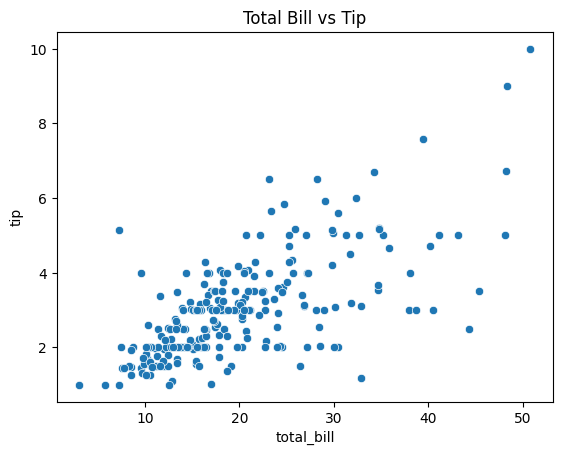

In [61]:
sns.scatterplot(x='total_bill', y='tip', data=df)
plt.title('Total Bill vs Tip')

In [62]:
# split the data into features and target variable
X = df[['total_bill']]
# scalar = MinMaxScaler()
# X = scalar.fit_transform(X)
# X = scalar.fit_transform(X)

y = df['tip']

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  


In [63]:
# Call the model
model = LinearRegression()

In [64]:
# Train the model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
model.predict([[20]])

c:\Users\mypci\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.0645097])

In [66]:
# Predict the values
y_pred = model.predict(X_test)

In [67]:
# Take out model intercept and slope, make an equation
print(model.intercept_)
print(model.coef_)
print('y = ', model.intercept_, '+', model.coef_, '* X')

0.9252355585570546
[0.10696371]
y =  0.9252355585570546 + [0.10696371] * X


In [68]:
y =  0.9252355585570546 + (0.10696371 * 20 )
y

3.0645097585570547

In [69]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print('Mean Squared Error:', mse)
print('R^2 Score:', r2)
print('Root Mean Squared Error:', rmse)

Mean Squared Error: 0.5688142529229538
R^2 Score: 0.5449381659234663
Root Mean Squared Error: 0.7541977545199626


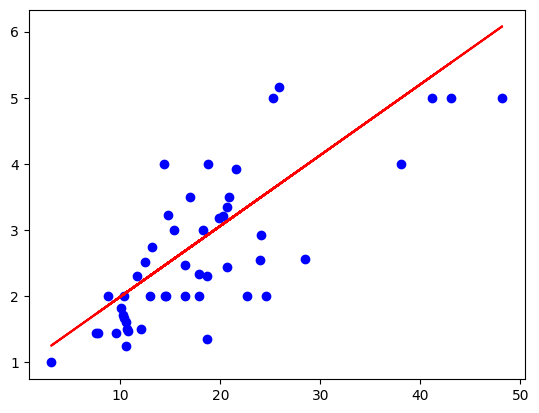

In [70]:
# plot the model and data
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')

Mean Squared Error: 0.6485996190543517
R^2 Score: 0.4811084097989491
Root Mean Squared Error: 0.8053568271607013


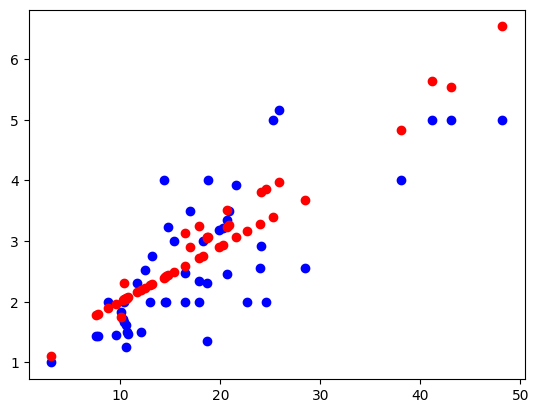

In [71]:
# Multiple Linear Regression
X = df[['total_bill', 'size']]
y = df['tip']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print('Mean Squared Error:', mse)
print('R^2 Score:', r2)
print('Root Mean Squared Error:', rmse)

plt.scatter(X_test['total_bill'], y_test, color='blue', label='Actual')
plt.scatter(X_test['total_bill'], y_pred, color='red', label='Predicted')

#### Diamonds dataset

The Diamonds dataset is a popular dataset used for regression analysis. It contains information about various attributes of diamonds, such as carat weight, cut, color, clarity, and price. The goal is to predict the price of a diamond based on its attributes.

In [8]:
diamonds = sns.load_dataset('diamonds')
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [9]:
X = diamonds[['carat', 'depth', 'table', 'x', 'y', 'z']]
y = diamonds['price']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_pred = model.predict(X_test)

In [13]:
model.predict([[0.85, 61.8, 57, 6.05, 6.02, 3.73]])

c:\Users\mypci\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([4141.25113637])

In [14]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)   
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R^2 Score:', r2)

Mean Squared Error: 2242178.904085608
Root Mean Squared Error: 1497.3906985438398
R^2 Score: 0.8589542625888935


#### After learning pipelines and hyperparamter tuning

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.datasets import fetch_california_housing
from xgboost import XGBRegressor

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['target'] = housing.target

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    #('model', LinearRegression())
    ('model', XGBRegressor())
])


score = cross_val_score(pipeline, X_train, y_train, cv=5).mean()

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("Cross Validation R2 Score: ", score)
print("R2 Score: ", r2)

Cross Validation R2 Score:  0.8300138900993232
R2 Score:  0.8301370561019205


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn import clone
from sklearn.model_selection import KFold

In [41]:
df = sns.load_dataset('tips')

X = df.drop('tip', axis=1)
y = df['tip']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = [
    ('Random Forest', RandomForestRegressor()),
    ('XGBoost', XGBRegressor()),
    ('Linear Regression', LinearRegression()),
    ('SVM Regressor', SVR()),
    ('KNN', KNeighborsRegressor()),
]

numeric_features = ['total_bill', 'size']
categorical_features = ['sex', 'smoker', 'day', 'time']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('nom_cat', categorical_transformer, categorical_features),
])

for name, model in models:
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    mean_r2 = scores.mean()

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = r2_score(y_test, y_pred)

    # Print the performance metrics
    print("Model:", name)
    print("Cross-validation Accuracy:", mean_r2)
    print("Test Accuracy:", accuracy)
    print()


# param_grid = {
#    'model__n_estimators': [100, 200, 300],
#    'model__learning_rate': [0.01, 0.1, 0.2],
#    'model__max_depth': [3, 4, 5]
#}
#
#grid = GridSearchCV(
#    estimator=pipeline,
##    param_grid=param_grid,
#    cv=5,
#    scoring='r2',
#    verbose=1,
#    n_jobs=-1
#)


Model: Random Forest
Cross-validation Accuracy: 0.3640865796075685
Test Accuracy: 0.2274725939340141

Model: XGBoost
Cross-validation Accuracy: 0.14881155514793037
Test Accuracy: 0.2561708340945843

Model: Linear Regression
Cross-validation Accuracy: 0.3105155818559277
Test Accuracy: 0.43730181943482516

Model: SVM Regressor
Cross-validation Accuracy: 0.3284387971035546
Test Accuracy: 0.42558767775531947

Model: KNN
Cross-validation Accuracy: 0.33272230376502127
Test Accuracy: 0.2872922661250843

